##**ANALISIS PENGARUH FAKTOR SOSIAL EKONOMI TERHADAP TINGKAT AKREDITASI PENDIDIKAN DI PROVINSI JAWA TIMUR TAHUN 2024**

Madina Hedy Alifanti			24083010001

Maulida Aprilia Putri Handayani	24083010057

Fatma Novalia Kussumarani		24083010098


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
df = pd.read_csv("data_butuhbubuk.csv")
df

,Kabupaten/Kota,GK,RLS,PDRB,TPT,PM,SKOR
0,Kabupaten Pacitan,370643,7.90,0.65,1.56,73.03,4.000000
1,Kabupaten Ponorogo,413619,7.80,0.85,4.19,80.05,3.280000
2,Kabupaten Trenggalek,434146,7.92,0.77,3.90,73.75,3.000000
3,Kabupaten Tulungagung,447793,8.68,1.61,4.12,66.42,3.107143
4,Kabupaten Blitar,408399,7.87,1.51,4.77,95.91,3.657895
5,Kabupaten Kediri,403621,8.26,1.72,5.10,159.27,3.543860
6,Kabupaten Malang,420334,7.80,4.36,5.13,240.14,3.455696
7,Kabupaten Lumajang,405136,7.27,1.36,3.28,91.05,2.968254
8,Kabupaten Jember,459043,6.54,3.24,3.23,224.77,2.926829
9,Kabupaten Banyuwangi,470713,7.78,3.43,4.03,106.61,3.366667


GK : Garis Kemiskinan

RLS : Rata-rata Lama Sekolah

PDRB : Produk Domestik Regional Bruto per Kapita

TPT : Tingkat Pengangguran Terbuka

PM : Penduduk Miskin

SKOR : Skor Akreditasi Pendidikan

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38 entries, 0 to 37
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Kabupaten/Kota  38 non-null     object 
 1   GK              38 non-null     int64  
 2   RLS             38 non-null     float64
 3   PDRB            38 non-null     float64
 4   TPT             38 non-null     float64
 5   PM              38 non-null     float64
 6   SKOR            38 non-null     float64
dtypes: float64(5), int64(1), object(1)
memory usage: 2.2+ KB


In [4]:
df.isnull().sum()

,0
Kabupaten/Kota,0
GK,0
RLS,0
PDRB,0
TPT,0
PM,0
SKOR,0


In [5]:
df.describe()

,GK,RLS,PDRB,TPT,PM,SKOR
count,38.000000,38.000000,38.000000,38.000000,38.000000,38.000000
mean,514364.026316,8.463947,2.630789,4.041316,104.808684,3.283985
std,91405.825701,1.703252,4.131199,1.176755,65.334860,0.441423
min,370643.000000,5.080000,0.270000,1.560000,6.590000,2.109756
25%,448366.750000,7.477500,0.772500,3.367500,68.072500,3.000000
50%,499161.000000,8.060000,1.390000,4.075000,107.490000,3.300264
75%,585627.500000,9.832500,3.195000,4.735000,146.445000,3.509616
max,742678.000000,12.110000,24.340000,6.490000,240.140000,4.000000


###**Uji Korelasi**

In [6]:
corr_matrix = df.corr(numeric_only=True)
corr_matrix

,GK,RLS,PDRB,TPT,PM,SKOR
GK,1.000000,0.685054,0.426124,0.411178,-0.377779,0.233956
RLS,0.685054,1.000000,0.300821,0.500759,-0.712114,0.712840
PDRB,0.426124,0.300821,1.000000,0.361652,0.157756,0.103607
TPT,0.411178,0.500759,0.361652,1.000000,-0.099390,0.350161
PM,-0.377779,-0.712114,0.157756,-0.099390,1.000000,-0.535849
SKOR,0.233956,0.712840,0.103607,0.350161,-0.535849,1.000000


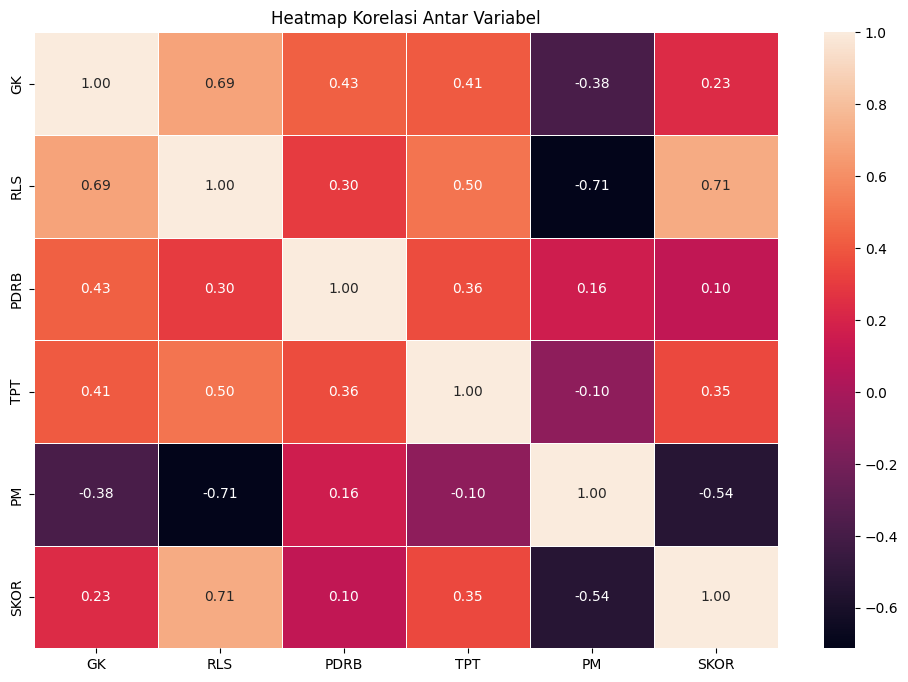

In [7]:
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", linewidths=0.5)
plt.title("Heatmap Korelasi Antar Variabel")
plt.show()

Berdasarkan heatmap korelasi, variabel yang paling kuat hubungannya dengan SKOR adalah Rata-rata Lama Sekolah (RLS) dengan korelasi positif sebesar 0.71, menunjukkan bahwa semakin tinggi rata-rata lama sekolah di suatu daerah, semakin tinggi pula nilai SKOR yang dihasilkan. GK, TPT, dan PDRB memiliki hubungan positif lemah hingga sedang terhadap SKOR, sedangkan variabel PM menunjukkan korelasi negatif sebesar –0.54, mengindikasikan bahwa meningkatnya PM cenderung menurunkan SKOR. Pola ini menunjukkan bahwa faktor pendidikan memiliki pengaruh paling besar dalam pembentukan SKOR, sementara PM justru menjadi faktor penghambat.

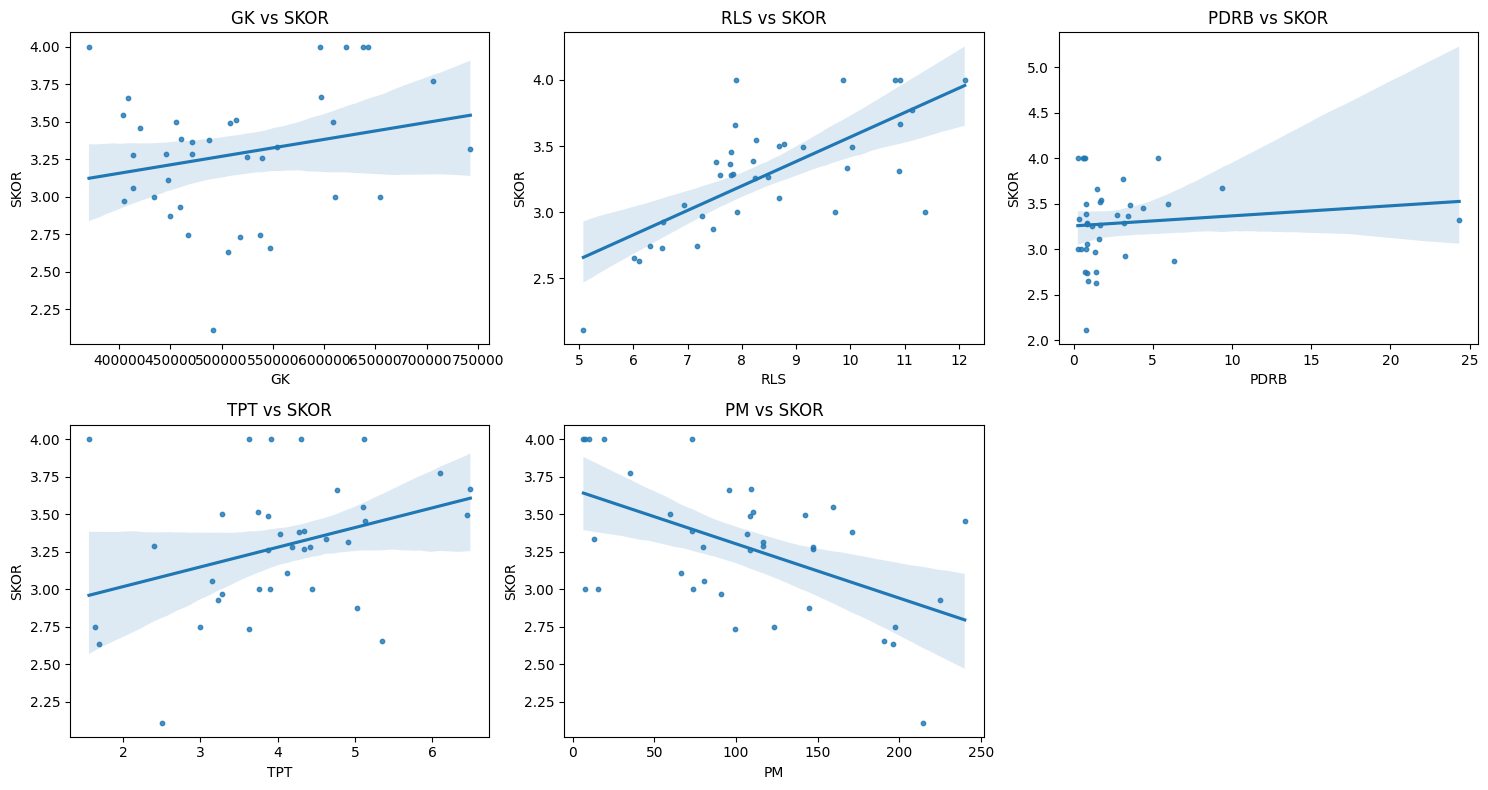

In [8]:
import math

target = "SKOR"

num_cols = df.select_dtypes(include=['int64','float64']).columns
num_cols = [c for c in num_cols if c != target]

n = len(num_cols)
cols = 3
rows = math.ceil(n / cols)

plt.figure(figsize=(cols*5, rows*4))

for i, col in enumerate(num_cols, 1):
    plt.subplot(rows, cols, i)
    sns.regplot(x=df[col], y=df[target], scatter_kws={'s':10})
    plt.xlabel(col)
    plt.ylabel(target)
    plt.title(f"{col} vs {target}")

plt.tight_layout()
plt.show()

Scatter plot antara setiap variabel dan SKOR menunjukkan pola hubungan yang bervariasi. Variabel GK terlihat memiliki hubungan positif yang lemah dengan SKOR, ditunjukkan oleh garis regresi yang sedikit menanjak dan sebaran data yang cukup tersebar. RLS menunjukkan hubungan paling kuat, dengan garis regresi yang jelas naik dan titik-titik yang lebih mengikuti pola linear, sehingga semakin tinggi rata-rata lama sekolah, semakin tinggi pula SKOR. PDRB tampak memiliki hubungan yang sangat lemah terhadap SKOR karena garis regresinya hampir datar dan sebaran titik sangat meluas. Variabel TPT menunjukkan hubungan positif lemah hingga sedang, meskipun sebaran datanya tidak terlalu teratur. Sementara itu, PM memiliki hubungan negatif yang relatif kuat, di mana meningkatnya PM cenderung menurunkan SKOR, terlihat dari garis regresi menurun yang cukup jelas.

###**REGRESI LOGISTIK**

In [9]:
df['Akreditasi'] = np.where(df['SKOR'] >= 3, 0, 1)

In [10]:
df

,Kabupaten/Kota,GK,RLS,PDRB,TPT,PM,SKOR,Akreditasi
0,Kabupaten Pacitan,370643,7.90,0.65,1.56,73.03,4.000000,0
1,Kabupaten Ponorogo,413619,7.80,0.85,4.19,80.05,3.280000,0
2,Kabupaten Trenggalek,434146,7.92,0.77,3.90,73.75,3.000000,0
3,Kabupaten Tulungagung,447793,8.68,1.61,4.12,66.42,3.107143,0
4,Kabupaten Blitar,408399,7.87,1.51,4.77,95.91,3.657895,0
5,Kabupaten Kediri,403621,8.26,1.72,5.10,159.27,3.543860,0
6,Kabupaten Malang,420334,7.80,4.36,5.13,240.14,3.455696,0
7,Kabupaten Lumajang,405136,7.27,1.36,3.28,91.05,2.968254,1
8,Kabupaten Jember,459043,6.54,3.24,3.23,224.77,2.926829,1
9,Kabupaten Banyuwangi,470713,7.78,3.43,4.03,106.61,3.366667,0


0 = Akreditasi tinggi

1 = Akreditasi rendah

In [11]:
target = "Akreditasi"
features = ["GK", "RLS", "PDRB", "TPT", "PM"]

In [12]:
X = df[features]
y = df[target]

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [14]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [15]:
y_pred = model.predict(X_test)

print("Akurasi  :", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Akurasi  : 0.875

Classification Report:
              precision    recall  f1-score   support

           0       0.83      1.00      0.91         5
           1       1.00      0.67      0.80         3

    accuracy                           0.88         8
   macro avg       0.92      0.83      0.85         8
weighted avg       0.90      0.88      0.87         8



Akurasi model mencapai 87.5% yang berarti seluruh data uji yang dibuat oleh model sudah benar.


Pada kategori 0, model menunjukkan performa yang sangat baik. Precision sebesar 0.83 menunjukkan bahwa ketika model memprediksi, sebagian besar prediksi tersebut benar. Recall yang mencapai 1.00 menandakan bahwa model tidak pernah melewatkan satupun data yang sebenarnya. Dengan itu, semua data aktual berhasil dikenali dengan benar sehingga F1-Score nya mencapai 0.91.

Pada kategori 1, precision sebesar 1.00 menunjukkan bahwa setiap prediksi yang dibuat model selalu benar dan tanpa kesalahan. Namun, recall sebesar 0.67 menunjukkan bahwa model hanya mampu mendeteksi sekitar dua pertiga dari seluruh data yang sebenarnya. Masih terdapat beberapa nilai yang salah diklasifikasikan. Hal ini membuat F1-Score menjadi 0.8 walaupun tetap tergolong cukup baik.

In [16]:
print("\nConfusion Matrix:")
confusion_matrix(y_test, y_pred)


Confusion Matrix:


array([[5, 0],
       [1, 2]])

Confusion matrix menunjukkan bagaimana model melakukan prediksi pada setiap kategorik
- Terdapat 5 data pada kategori 0 yang diprediksi dengan benar
- Tidak ada data kategori 0 yang salah diprediksi sebagai kategori 1
- Untuk kategori 1, terdapat 2 data yang berhasil diprediksi dengan benar
- Namun, terdapat 1 data yang salah diklasifikasikan sebagai kategori 0


In [17]:
coef = pd.DataFrame({
    "Fitur": X.columns,
    "Koefisien": model.coef_[0]
})

print("\nKoefisien Model:")
coef


Koefisien Model:


,Fitur,Koefisien
0,GK,0.000004
1,RLS,-1.463082
2,PDRB,-0.408649
3,TPT,-0.338912
4,PM,0.020751


1. Garis Kemiskinan: Koefisien GK bernilai positif, ini menunjukkan bahwa kenaikan garis kemiskinan di suatu daerah cenderung meningkatkan log-odds terjadinya akreditasi rendah. Pengaruh GK terhadap Akreditasi sangat lemah dan tidak substansial dengan model.
2. Rata-rata Lama Sekolah: RLS memiliki koefisien negatif, menunjukkan bahwa variabel ini memiliki pengaruh paling significant dibandingkan variabel lainnya. Koefisien negatif menandakan bahwa semakin tinggi rata-rata lama sekolah penduduk suatu daerah, semakin kecil peluang kabupaten/kota masuk dalam kategori akreditasi rendah.
3. PDRB: Koefisien PDRB yang bernilai negatif menunjukkan bahwa pertumbuhan ekonomi yang lebih baik berasosiasi dengan menurunnya peluang suatu daerah memiliki akreditasi pendidikan yang rendah.
4. TPT: Koefisien TPT bernilai negatif yang berarti kenaikan tingkat pengangguran secara statistik menurunkan peluang akreditasi rendah.
5. PM: Koefisien PM bernilai positif ini menunjukkan bahwa semakin tinggi proporsi penduduk miskini di suatu daerah, semakin besar peluang kabupaten/kota tersebut berada pada kategori akreditasi rendah.

###**Regresi Dummy**

In [18]:
median_rls = df['RLS'].median()
median_pdrb = df['PDRB'].median()

print("Median RLS:", median_rls)

print("Median PDRB:", median_pdrb)

Median RLS: 8.059999999999999
Median PDRB: 1.3900000000000001


In [19]:
df['RLS_dummy'] = (df['RLS'] >= median_rls).astype(int)
df['PDRB_dummy'] = (df['PDRB'] >= median_pdrb).astype(int)

df[['Kabupaten/Kota','RLS', 'RLS_dummy', 'PDRB', 'PDRB_dummy']]

,Kabupaten/Kota,RLS,RLS_dummy,PDRB,PDRB_dummy
0,Kabupaten Pacitan,7.90,0,0.65,0
1,Kabupaten Ponorogo,7.80,0,0.85,0
2,Kabupaten Trenggalek,7.92,0,0.77,0
3,Kabupaten Tulungagung,8.68,1,1.61,1
4,Kabupaten Blitar,7.87,0,1.51,1
5,Kabupaten Kediri,8.26,1,1.72,1
6,Kabupaten Malang,7.80,0,4.36,1
7,Kabupaten Lumajang,7.27,0,1.36,0
8,Kabupaten Jember,6.54,0,3.24,1
9,Kabupaten Banyuwangi,7.78,0,3.43,1


In [20]:
X = df[['RLS_dummy', 'PDRB_dummy']]
y = df['SKOR']

In [21]:
from scipy.stats import pearsonr

In [22]:
corr, _ = pearsonr(df['RLS_dummy'], df['SKOR'])
print('Korelasi Pearson:', corr)

Korelasi Pearson: 0.5132160737344758


Berdasarkan hasil korelasi pearson sebesar 0,513 maka dapat disimpulkan bahwa variabel RLS dengan variabel skor akreditasi memiliki hubungan korelasi positif sedang.

In [23]:
corr, _ = pearsonr(df['PDRB_dummy'], df['SKOR'])
print('Korelasi Pearson:', corr)

Korelasi Pearson: 0.13153720248029646


Berdasarkan hasil korelasi pearson nilai sebesar 0,131 maka dapat disimpulkan bahwa variabel PDRB dengan variabel skor akreditasi memiliki hubungan korelasi positif lemah karena nilai koefisien korelasi sangat mendekati 0.

In [24]:
import scipy.stats as stats

In [25]:
stats.pointbiserialr(df['RLS_dummy'], df['SKOR'])

SignificanceResult(statistic=np.float64(0.5132160737344758), pvalue=np.float64(0.0009841068950581084))

Berdasarkan nilai korelasi biserial poin sebesar 0,513 maka dapat disimpulkan variabel RLS dengan skor akreditasi memiliki hubungan korelasi positif sedang, karena memiliki nilai koefisien korelasi lebih dari 0,4.

In [26]:
stats.pointbiserialr(df['PDRB_dummy'], df['SKOR'])

SignificanceResult(statistic=np.float64(0.13153720248029646), pvalue=np.float64(0.4311691517041808))

Berdasarkan nilai korelasi biserial poin sebesar 0,131 maka dapat disimpulkan variabel RLS dengan skor akreditasi memiliki hubungan korelasi positif lemah, karena memiliki nilai koefisien korelasi mendekati 0.

In [27]:
import statsmodels.formula.api as smf

In [28]:
import statsmodels.api as sm

In [29]:
# Variabel independen (tambah constant)
X = df[['RLS_dummy', 'PDRB_dummy']]
X = sm.add_constant(X)

# Variabel dependen
y = df['SKOR']

# Fit model
model = sm.OLS(y, X).fit()

# Tampilkan hasil
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:                   SKOR   R-squared:                       0.274
Model:                            OLS   Adj. R-squared:                  0.233
Method:                 Least Squares   F-statistic:                     6.616
Date:                Mon, 17 Nov 2025   Prob (F-statistic):            0.00365
Time:                        14:19:32   Log-Likelihood:                -16.245
No. Observations:                  38   AIC:                             38.49
Df Residuals:                      35   BIC:                             43.40
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          3.0172      0.107     28.249      0.0

Berdasarkan hasil tersebut diketahui bahwa variabel RLS memiliki pengaruh yang signifikan terhadap nilai skor akreditasi. Hal ini ditunjukkan oleh nilai koefisien positif sebesar 0,442 dengan nilai p-value 0,001, yang berarti wilayah dengan RLS di atas median cenderung memiliki skor sekitar 0,44 poin lebih tinggi dibandingkan wilayah dengan RLS di Bawah median. Sementara itu, variabel PDRB tidak menunjukkan pengaruh yang signifikan, dengan nilai koefisien 0,091 dan p-value 0,472. Walaupun memiliki berpengaruh positif, dari nilai tersebut peningkatan PDRB di atas median tidak terbukti memberikan skor akreditasi yang tinggi. Dari hasil tersebut dapat disimpulkan RLS memiliki kontribusi yang jauh lebih kuat dalam mempengaruhi skor akreditasi dibandingkan PDRB dalam model yang digunakan.

In [30]:
prediksi = model.predict(X)
prediksi

,0
0,3.017188
1,3.017188
2,3.017188
3,3.550782
4,3.108499
5,3.550782
6,3.108499
7,3.017188
8,3.108499
9,3.108499


Output tersebut merupakan hasil nilai prediksi y topi. Setiap nilai skor yang muncul ditentukan oleh kombinasi antara variabel RLS_dummy dan PDRB_dummy pada masing-masing kabupaten/kota. Pada model yang hanya memiliki dua variabel dummy maka nilai prediksi yang muncul hanya terdiri dari 4 kemungkinan. Salah satu contohnya yaitu baris pertama memiliki nilai output 0,3017, nilai oni muncul pada wilayah yang memiliki RLS_dummy = 0 dan PDRB_dummy = 0, yang artinya kabupaten/kota tersebut memiliki RLS dan PDRB di bawah median.

In [31]:
residual = model.resid
residual

,0
0,0.982812
1,0.262812
2,-0.017188
3,-0.443639
4,0.549396
5,-0.006922
6,0.347197
7,-0.048934
8,-0.181670
9,0.258168


Hasil output tersebut merupakan nilai residual, yang merupakan selisih antara nilai skor akreditasi dengan nilai skor yang diprediksi oleh model regresi. Contohnya pada baris pertama nilai residual sebesar 0,9828 yang artinya model memprediksi nilai skor akreditasi hampir 1 poin lebih rendah dibandingkan nilai aktualnya, hal ini menunjukkan model kurang akurat dalam memprediksi skor akreditasi untuk kabupaten/kota tersebut. Sebaliknya pada baris ke-4 nilai residual sebesar -0,4436 yang menunjukkan bahwa prediksi model lebih tinggi sebesar 0,44 poin dari nilai skor akreditasi sebenarnya.